# Solving the Traveling Salesman  Problem using Local Search

Points: 10

## The [Traveling Salesman Problem](https://en.wikipedia.org/wiki/Travelling_salesman_problem)

* __Goal:__ Find the shortest tour visiting each of $n$ cities exactly once and returning back to the starting city. Given are pairwise distances between cities, where $d_{i,j}$ is the distance from city $i$ to city $j$. 

* __State space:__ Each state represents a tour. The cities are numbered and a tour can be expressed as vector  $\pi$ with the order in which the cities are visited (a [permutation](https://en.wikipedia.org/wiki/Permutation)). That is, $\pi(1)$ is the index of the first city to visit, $\pi(2)$ the index of the second, and so on.

* __Objective function:__ Minimize the tour length. The optimization problem is to find the optimal tour $\pi^*$ through the $n$ cities and returning to the starting city:

  > minimize: $\mathrm{tourlength}(\pi) = d_{\pi(n),\pi(1)} + \sum_{i = 1}^{n-1} d_{\pi(i),\pi(i+1)}$
  > 
  > subject to: $\pi \ \text{is a valid permutation vector}$

* __Local moves:__ Exchange two cities in the order.

## Helper functions

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random

np.set_printoptions(precision=2)
# pd.set_option('precision', 2) #Trong pandas các version mới (>=1.0) thì option "precision" không còn tồn tại nữa.
pd.set_option("display.precision", 2)

# make the results repeatable
np.random.seed(1234)

In [74]:
def random_tour(n):
    """Create a random tour"""
    
    tour = list(range(n))
    random.shuffle(tour)
    return(tour)

random_tour(10)

[0, 8, 9, 1, 4, 5, 3, 7, 6, 2]

In [75]:
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform

def random_tsp(n):
    """
    Create a random (Euclidean) traveling salesman problem. Choose n points randomly in a 1 x 1 unit square and calulates a 
    pairwise Euclidean distance matrix.
    """
    
    pos = pd.DataFrame({
        "x" : np.random.uniform(size = n),
        "y" : np.random.uniform(size = n)
    })
    
    dist = squareform(pdist(pos))
    
    return({"pos": pos, "dist": dist})
    
tsp = random_tsp(10)

print(f"Positions:\n{tsp['pos']}")
print(f"Distance matrix:\n{pd.DataFrame(tsp['dist'])})")

Positions:
      x     y
0  0.19  0.36
1  0.62  0.50
2  0.44  0.68
3  0.79  0.71
4  0.78  0.37
5  0.27  0.56
6  0.28  0.50
7  0.80  0.01
8  0.96  0.77
9  0.88  0.88
Distance matrix:
      0     1     2     3     4     5     6     7     8     9
0  0.00  0.45  0.41  0.69  0.59  0.22  0.17  0.70  0.87  0.86
1  0.45  0.00  0.26  0.27  0.20  0.35  0.35  0.52  0.43  0.46
2  0.41  0.26  0.00  0.35  0.46  0.21  0.24  0.76  0.53  0.48
3  0.69  0.27  0.35  0.00  0.34  0.53  0.55  0.70  0.18  0.19
4  0.59  0.20  0.46  0.34  0.00  0.54  0.52  0.36  0.44  0.52
5  0.22  0.35  0.21  0.53  0.54  0.00  0.06  0.76  0.72  0.68
6  0.17  0.35  0.24  0.55  0.52  0.06  0.00  0.72  0.73  0.71
7  0.70  0.52  0.76  0.70  0.36  0.76  0.72  0.00  0.77  0.87
8  0.87  0.43  0.53  0.18  0.44  0.72  0.73  0.77  0.00  0.14
9  0.86  0.46  0.48  0.19  0.52  0.68  0.71  0.87  0.14  0.00)


In [76]:
def tour_length(tsp, tour):
    """Caclulate the length of a tour, i.e., the objective function."""
    
    # make sure tour is a Python list (not an array or a numpy.array)
    if not isinstance(tour, list): tour = tour.tolist()
    
    tl = 0
    dist = tsp["dist"]
    
    for i in range(len(tour)-1):
        tl += dist[tour[i], tour[i+1]]
    
    tl += dist[tour[-1], tour[0]]
    
    return(tl)
        
tour = random_tour(10)
tour_length(tsp, tour)

np.float64(3.856942641064816)

Tour length: 3.86


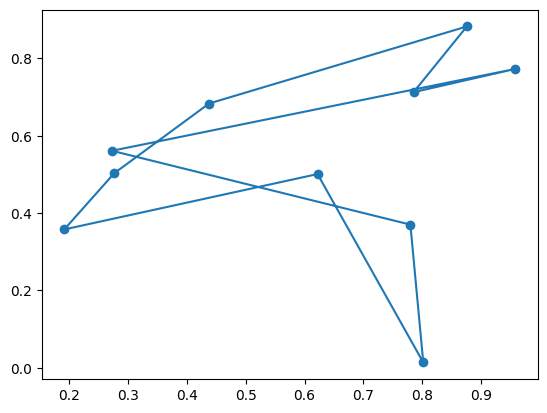

In [77]:
def show_tsp(tsp, tour = None):  
    """display the traveling salesman problem and a tour."""
    
    pos = tsp["pos"]
    
    plt.scatter(pos["x"], pos["y"])
    
    if tour is not None:
        # make sure tour is a Python list (not an array or a numpy.array)
        if not isinstance(tour, list): tour = tour.tolist()
        
        print(f"Tour length: {round(tour_length(tsp, tour), 2)}")
        
        # pos_ = pos.reindex(tour)
        # pos_ = pos_.append(pos_.head(1)) # code lỗi là do pandas mới (>= 2.0) đã xóa hẳn DataFrame.append().

        pos_ = pos.reindex(tour)
        pos_ = pd.concat([pos_, pos_.head(1)])


        plt.plot(pos_["x"], pos_["y"])
    
    plt.show()
    
show_tsp(tsp, tour)

## Use R to find a solution

Load rpy2, make sure the R [TSP package](https://CRAN.R-project.org/package=TSP) is installed and prepare the distance matrix.

In [78]:
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [79]:
%%R
version


               _                                
platform       x86_64-w64-mingw32               
arch           x86_64                           
os             mingw32                          
crt            ucrt                             
system         x86_64, mingw32                  
status                                          
major          4                                
minor          5.1                              
year           2025                             
month          06                               
day            13                               
svn rev        88306                            
language       R                                
version.string R version 4.5.1 (2025-06-13 ucrt)
nickname       Great Square Root                


In [80]:
%%R
if(!"TSP" %in% rownames(installed.packages())) {
    install.packages("TSP", repos="http://cran.us.r-project.org")
}
if(!"microbenchmark" %in% rownames(installed.packages())) {
    install.packages("microbenchmark", repos="http://cran.us.r-project.org")
}

library(TSP)

# ví dụ tạo dữ liệu khoảng cách
data("USCA312")   # dataset có sẵn trong TSP
tsp <- TSP(USCA312)

# lấy ma trận khoảng cách
d <- as.matrix(dist(tsp))




In [81]:
# %load_ext rpy2.ipython

# %R if(!"TSP" %in% rownames(installed.packages())) install.packages("TSP", repos="http://cran.us.r-project.org")
# %R if(!"microbenchmark" %in% rownames(installed.packages())) install.packages("microbenchmark", repos="http://cran.us.r-project.org")


# d = tsp["dist"]



Solve the TSP using [`solve_TSP`](https://www.rdocumentation.org/packages/TSP/versions/1.1-10/topics/solve_TSP) with the default heuristic. Note that 2-opt is steepest ascend hill climbing with exchanging two cities. `rep=100` means 100 random restarts.

In [82]:
%%R -i d -o tour

library("TSP")

tsp <- TSP(d)
print(tsp)

tour <- solve_TSP(tsp, rep = 100)
print(tour)

# R starts index with 1, but Python starts at 0
tour <- tour - 1L

object of class 'TSP' 
10 cities (distance 'unknown') 
object of class 'TOUR' 
result of method 'arbitrary_insertion+two_opt_rep_100' for 10 cities
tour length: 2.763574 


Tour length: 2.76


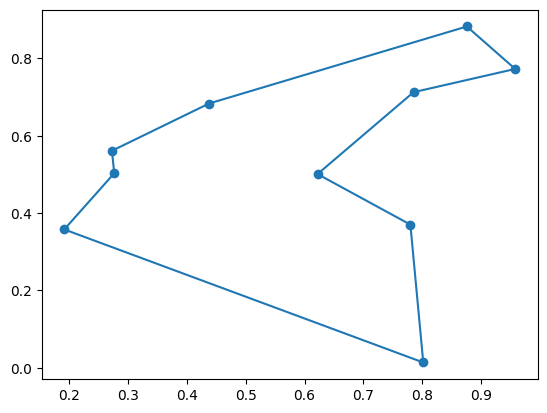

In [83]:
show_tsp(tsp, tour)

How long does it take to solve the problem 100 times?

In [84]:
%%R -i d

library("microbenchmark")

microbenchmark(tsp <- TSP(d))

Unit: microseconds
          expr min    lq    mean median     uq   max neval
 tsp <- TSP(d) 298 313.6 334.882  320.2 335.25 596.6   100


## Steepest-ascend Hill Climbing Search [3 Points]

Calculate the objective function for all local moves (move each queen within its column) and always choose the best among all local moves.

In [85]:
import random

def compute_conflicts(state):
    """
    Đếm số xung đột (conflicts) giữa các quân hậu.
    state[i] = row của quân hậu ở column i
    """
    n = len(state)
    conflicts = 0
    for i in range(n):
        for j in range(i+1, n):
            if state[i] == state[j] or abs(state[i]-state[j]) == abs(i-j):
                conflicts += 1
    return conflicts

def steepest_ascent_hill_climbing(n, max_steps=1000):
    # Khởi tạo trạng thái ngẫu nhiên
    state = [random.randint(0, n-1) for _ in range(n)]
    current_conflicts = compute_conflicts(state)

    for step in range(max_steps):
        best_state = None
        best_conflicts = current_conflicts

        # Sinh tất cả neighbor bằng cách move 1 quân hậu sang row khác
        for col in range(n):
            for row in range(n):
                if row != state[col]:
                    neighbor = list(state)
                    neighbor[col] = row
                    conflicts = compute_conflicts(neighbor)
                    if conflicts < best_conflicts:  # Tìm neighbor tốt nhất
                        best_conflicts = conflicts
                        best_state = neighbor

        # Nếu tìm được state tốt hơn → cập nhật
        if best_state:
            state = best_state
            current_conflicts = best_conflicts
        else:
            break  # không cải thiện → local optimum

        # Nếu không còn xung đột thì thành công
        if current_conflicts == 0:
            return state, True

    return state, False

# Ví dụ chạy với N=8
solution, success = steepest_ascent_hill_climbing(8)
print("Solution:", solution)
print("Success:", success)


Solution: [3, 6, 3, 1, 4, 7, 0, 2]
Success: False


## Steepest-ascend Hill Climbing Search with Random Restarts [1 Point]

Steepest-ascend with random restarts.

In [86]:
# Code goes here
import random
import numpy as np

def tour_length(tsp, tour):
    """Tính độ dài một tour"""
    dist = tsp["dist"]
    return sum(dist[tour[i], tour[(i+1)%len(tour)]] for i in range(len(tour)))

def get_best_neighbor(tsp, tour):
    """Sinh tất cả neighbor bằng cách hoán đổi 2 thành phố, chọn cái tốt nhất"""
    best_tour = tour
    best_len = tour_length(tsp, tour)
    
    for i in range(len(tour)):
        for j in range(i+1, len(tour)):
            neighbor = tour[:]
            neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
            l = tour_length(tsp, neighbor)
            if l < best_len:
                best_len = l
                best_tour = neighbor
    return best_tour, best_len

def steepest_ascent_hc_rr(tsp, max_restarts=10):
    """Steepest-Ascent Hill Climbing with Random Restarts"""
    n = len(tsp["dist"])
    best_global_tour = None
    best_global_len = float("inf")
    
    for restart in range(max_restarts):
        # random start
        tour = list(range(n))
        random.shuffle(tour)
        
        improved = True
        while improved:
            neighbor, neighbor_len = get_best_neighbor(tsp, tour)
            if neighbor_len < tour_length(tsp, tour):
                tour = neighbor
            else:
                improved = False
        
        final_len = tour_length(tsp, tour)
        if final_len < best_global_len:
            best_global_len = final_len
            best_global_tour = tour
    
    return best_global_tour, best_global_len

# Ví dụ chạy thử (giả sử tsp["dist"] là ma trận khoảng cách numpy)
n_cities = 6
coords = np.random.rand(n_cities, 2) * 100
dist_matrix = np.sqrt(((coords[:,None,:]-coords[None,:,:])**2).sum(axis=2))
tsp = {"dist": dist_matrix, "pos": {"x": coords[:,0], "y": coords[:,1]}}

best_tour, best_len = steepest_ascent_hc_rr(tsp, max_restarts=20)
print("Best tour:", best_tour)
print("Best length:", best_len)


Best tour: [2, 3, 0, 4, 1, 5]
Best length: 213.11902860577723


## Stochastic Hill Climbing [1 Points]

Chooses randomly from among all uphill moves.

In [87]:
# Code goes here
import random
import numpy as np

def stochastic_hill_climbing(tsp, max_iterations=1000):
    n = len(tsp["dist"])
    
    # Random start
    tour = list(range(n))
    random.shuffle(tour)
    current_len = tour_length(tsp, tour)
    
    for _ in range(max_iterations):
        uphill_moves = []
        
        # Tìm tất cả neighbor có cải thiện
        for i in range(n):
            for j in range(i+1, n):
                neighbor = tour[:]
                neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
                l = tour_length(tsp, neighbor)
                if l < current_len:  # chỉ chọn uphill moves
                    uphill_moves.append((neighbor, l))
        
        if not uphill_moves:
            break  # không còn move nào cải thiện → dừng
        
        # Chọn random 1 move từ danh sách uphill
        tour, current_len = random.choice(uphill_moves)
    
    return tour, current_len


# Ví dụ chạy thử
n_cities = 6
coords = np.random.rand(n_cities, 2) * 100
dist_matrix = np.sqrt(((coords[:,None,:]-coords[None,:,:])**2).sum(axis=2))
tsp = {"dist": dist_matrix, "pos": {"x": coords[:,0], "y": coords[:,1]}}

best_tour, best_len = stochastic_hill_climbing(tsp, max_iterations=500)
print("Best tour:", best_tour)
print("Best length:", best_len)


Best tour: [1, 0, 4, 5, 2, 3]
Best length: 266.31023731729596


## First-choice Hill Climbing [1 Point]

First-choice hill climbing is a type of stochastic hill climbing that generates one random local neighbor at a time and accept it if it has a better objective function value than the current state.

In [88]:
# Code goes here
import random
import numpy as np

def first_choice_hill_climbing(tsp, max_iterations=1000):
    n = len(tsp["dist"])
    
    # Khởi tạo tour random
    tour = list(range(n))
    random.shuffle(tour)
    current_len = tour_length(tsp, tour)
    
    for _ in range(max_iterations):
        # Tạo 1 neighbor ngẫu nhiên
        i, j = random.sample(range(n), 2)
        neighbor = tour[:]
        neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
        
        # Tính độ dài neighbor
        l = tour_length(tsp, neighbor)
        
        # Nếu tốt hơn → chấp nhận ngay
        if l < current_len:
            tour, current_len = neighbor, l
    
    return tour, current_len


# ================== TEST ================== #
n_cities = 6
coords = np.random.rand(n_cities, 2) * 100
dist_matrix = np.sqrt(((coords[:,None,:]-coords[None,:,:])**2).sum(axis=2))
tsp = {"dist": dist_matrix, "pos": {"x": coords[:,0], "y": coords[:,1]}}

best_tour, best_len = first_choice_hill_climbing(tsp, max_iterations=500)
print("Best tour:", best_tour)
print("Best length:", best_len)


Best tour: [3, 5, 0, 4, 2, 1]
Best length: 242.14901468086674


## Simulated Annealing [2 Points]

In [89]:
# Code goes here
import random
import numpy as np
import math

def simulated_annealing(tsp, T=1000, cooling_rate=0.995, max_iterations=1000):
    n = len(tsp["dist"])
    
    # Khởi tạo tour random
    current = list(range(n))
    random.shuffle(current)
    current_len = tour_length(tsp, current)
    
    best = current[:]
    best_len = current_len
    
    for _ in range(max_iterations):
        # Tạo neighbor bằng swap
        i, j = random.sample(range(n), 2)
        neighbor = current[:]
        neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
        neighbor_len = tour_length(tsp, neighbor)
        
        # ΔE
        delta = neighbor_len - current_len
        
        # Nếu tốt hơn hoặc chấp nhận theo xác suất
        if delta < 0 or random.random() < math.exp(-delta / T):
            current, current_len = neighbor, neighbor_len
            
            # Cập nhật best
            if current_len < best_len:
                best, best_len = current[:], current_len
        
        # Giảm nhiệt độ
        T *= cooling_rate
        if T < 1e-8:
            break
    
    return best, best_len


# ================== TEST ================== #
n_cities = 6
coords = np.random.rand(n_cities, 2) * 100
dist_matrix = np.sqrt(((coords[:,None,:]-coords[None,:,:])**2).sum(axis=2))
tsp = {"dist": dist_matrix, "pos": {"x": coords[:,0], "y": coords[:,1]}}

best_tour, best_len = simulated_annealing(tsp, T=1000, cooling_rate=0.995, max_iterations=2000)
print("Best tour (SA):", best_tour)
print("Best length (SA):", best_len)


Best tour (SA): [1, 3, 4, 2, 5, 0]
Best length (SA): 251.0720455762909


## Compare Performance [2 Points]

Use runtime, scalability (number of cities), and best objective function value to compare the algorithms on boards of different sizes.  

For timing you can use the `time` package.

In [90]:
import time

t0 = time.time()
print("Do something")
t1 = time.time()

print(f"This took: {(t1-t0) * 1e3} milliseconds")



Do something
This took: 0.0 milliseconds


In [91]:
# Code and results go here
import random
import math
import time
import pandas as pd

# ===== Utility functions =====
def generate_tsp(n_cities, seed=42):
    random.seed(seed)
    cities = [(random.random(), random.random()) for _ in range(n_cities)]
    return cities

def distance(a, b):
    return math.dist(a, b)

def total_distance(tour, cities):
    return sum(distance(cities[tour[i]], cities[tour[(i+1)%len(tour)]]) for i in range(len(tour)))

def random_neighbor(tour):
    i, j = random.sample(range(len(tour)), 2)
    new_tour = tour[:]
    new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
    return new_tour

# ===== Algorithms =====
def steepest_ascent(cities, max_iter=500):
    current = list(range(len(cities)))
    random.shuffle(current)
    best_val = total_distance(current, cities)
    
    improved = True
    while improved:
        improved = False
        best_neighbor, best_neighbor_val = None, best_val
        for _ in range(max_iter):
            neighbor = random_neighbor(current)
            val = total_distance(neighbor, cities)
            if val < best_neighbor_val:
                best_neighbor, best_neighbor_val = neighbor, val
                improved = True
        if improved:
            current, best_val = best_neighbor, best_neighbor_val
    return current, best_val


def stochastic_hill_climbing(cities, max_iter=1000):
    current = list(range(len(cities)))
    random.shuffle(current)
    best_val = total_distance(current, cities)
    
    for _ in range(max_iter):
        neighbor = random_neighbor(current)
        val = total_distance(neighbor, cities)
        if val < best_val:
            current, best_val = neighbor, val
    return current, best_val


def first_choice_hill_climbing(cities, max_iter=1000):
    current = list(range(len(cities)))
    random.shuffle(current)
    best_val = total_distance(current, cities)
    
    for _ in range(max_iter):
        neighbor = random_neighbor(current)
        val = total_distance(neighbor, cities)
        if val < best_val:
            current, best_val = neighbor, val
    return current, best_val


def simulated_annealing(cities, max_iter=1000, T=1000, alpha=0.995):
    current = list(range(len(cities)))
    random.shuffle(current)
    best = current[:]
    best_val = total_distance(current, cities)
    
    for _ in range(max_iter):
        T *= alpha
        neighbor = random_neighbor(current)
        val = total_distance(neighbor, cities)
        delta = val - total_distance(current, cities)
        if delta < 0 or random.random() < math.exp(-delta/T):
            current = neighbor
            if val < best_val:
                best, best_val = neighbor, val
    return best, best_val


# ===== Compare function =====
def compare_algorithms(city_sizes):
    results = []
    for n in city_sizes:
        cities = generate_tsp(n)

        # Steepest-Ascent
        t0 = time.time()
        _, val = steepest_ascent(cities)
        t1 = time.time()
        results.append(["Steepest-Ascent", n, val, (t1-t0)*1000])

        # Stochastic HC
        t0 = time.time()
        _, val = stochastic_hill_climbing(cities)
        t1 = time.time()
        results.append(["Stochastic HC", n, val, (t1-t0)*1000])

        # First-choice HC
        t0 = time.time()
        _, val = first_choice_hill_climbing(cities)
        t1 = time.time()
        results.append(["First-choice HC", n, val, (t1-t0)*1000])

        # Simulated Annealing
        t0 = time.time()
        _, val = simulated_annealing(cities)
        t1 = time.time()
        results.append(["Simulated Annealing", n, val, (t1-t0)*1000])

        # Genetic Algorithm
        t0 = time.time()
        _, val = genetic_algorithm(cities, pop_size=50, generations=300)
        t1 = time.time()
        results.append(["Genetic Algorithm", n, val, (t1-t0)*1000])

    
    return pd.DataFrame(results, columns=["Algorithm", "Cities", "Best Distance", "Runtime (ms)"])


# ========== TEST ==========
df_results = compare_algorithms([10, 20, 50])
print(df_results)



              Algorithm  Cities  Best Distance  Runtime (ms)
0       Steepest-Ascent      10           2.64         17.63
1         Stochastic HC      10           2.64          7.14
2       First-choice HC      10           2.64          5.76
3   Simulated Annealing      10           3.32         10.59
4     Genetic Algorithm      10           2.64        470.79
5       Steepest-Ascent      20           3.63         76.34
6         Stochastic HC      20           4.56          6.94
7       First-choice HC      20           4.24          6.96
8   Simulated Annealing      20           7.39         13.46
9     Genetic Algorithm      20           3.96        784.26
10      Steepest-Ascent      50           8.72        353.90
11        Stochastic HC      50          12.28         13.83
12      First-choice HC      50          10.11         13.89
13  Simulated Annealing      50          21.27         34.65
14    Genetic Algorithm      50          12.06       1784.47


## Bonus: Genetic Algorithm [+1 Point]

In [92]:
# Code goes here
import random
import math

# ====== Utility functions (reuse từ trước) ======
def total_distance(tour, cities):
    return sum(math.dist(cities[tour[i]], cities[tour[(i+1)%len(tour)]]) for i in range(len(tour)))

def generate_tsp(n_cities, seed=42):
    random.seed(seed)
    cities = [(random.random(), random.random()) for _ in range(n_cities)]
    return cities

# ====== Genetic Algorithm ======
def initial_population(pop_size, n_cities):
    population = []
    for _ in range(pop_size):
        tour = list(range(n_cities))
        random.shuffle(tour)
        population.append(tour)
    return population

def selection(population, cities, k=3):
    """ Tournament selection """
    selected = random.sample(population, k)
    selected.sort(key=lambda t: total_distance(t, cities))
    return selected[0]

def crossover(parent1, parent2):
    """ Order Crossover (OX) """
    size = len(parent1)
    start, end = sorted(random.sample(range(size), 2))
    child = [None]*size
    child[start:end] = parent1[start:end]
    
    fill_pos = end
    for gene in parent2:
        if gene not in child:
            if fill_pos >= size:
                fill_pos = 0
            child[fill_pos] = gene
            fill_pos += 1
    return child

def mutate(tour, mutation_rate=0.1):
    if random.random() < mutation_rate:
        i, j = random.sample(range(len(tour)), 2)
        tour[i], tour[j] = tour[j], tour[i]
    return tour

def genetic_algorithm(cities, pop_size=50, generations=500, mutation_rate=0.1):
    n_cities = len(cities)
    population = initial_population(pop_size, n_cities)
    
    best = min(population, key=lambda t: total_distance(t, cities))
    best_val = total_distance(best, cities)
    
    for _ in range(generations):
        new_population = []
        for _ in range(pop_size):
            p1 = selection(population, cities)
            p2 = selection(population, cities)
            child = crossover(p1, p2)
            child = mutate(child, mutation_rate)
            new_population.append(child)
        
        population = new_population
        current_best = min(population, key=lambda t: total_distance(t, cities))
        current_val = total_distance(current_best, cities)
        if current_val < best_val:
            best, best_val = current_best, current_val
    
    return best, best_val

df_results = compare_algorithms([10, 20, 50])
print(df_results)



              Algorithm  Cities  Best Distance  Runtime (ms)
0       Steepest-Ascent      10           2.64         17.85
1         Stochastic HC      10           2.64          9.37
2       First-choice HC      10           2.64          5.71
3   Simulated Annealing      10           3.32          6.95
4     Genetic Algorithm      10           2.64        428.88
5       Steepest-Ascent      20           3.63         54.82
6         Stochastic HC      20           4.56          6.95
7       First-choice HC      20           4.24         13.52
8   Simulated Annealing      20           7.39          7.28
9     Genetic Algorithm      20           3.96        693.83
10      Steepest-Ascent      50           8.72        319.09
11        Stochastic HC      50          12.28         13.80
12      First-choice HC      50          10.11         15.69
13  Simulated Annealing      50          21.27         19.01
14    Genetic Algorithm      50          12.06       1688.83
